# MNIST Digits Classification with TensorFlow Serving

<a target="_blank" href="https://colab.research.google.com/github/LuisAngelMendozaVelasco/luisangelmendozavelasco.github.io/blob/master/_portfolio/TensorFlow-Data_and_Deployment/portfolio-7.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png">Run in Google Colab</a>

**Objective:** Train a Neural Network to classify images of handwritten digits from the MNIST dataset and serve it using TensorFlow Serving.

[TensorFlow Serving](https://www.tensorflow.org/tfx/guide/serving) is a flexible, high-performance serving system designed for deploying machine learning models in production environments. It handles the inference aspect of ML by managing model lifetimes and providing clients with versioned access via a high-performance, reference-counted lookup table. 

**Warning: This notebook is designed to be run in a Google Colab only. It installs packages on the system and requires root access.**

## Import libraries

In [1]:
import keras
from keras import Input, layers, Sequential
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import json
import requests
import os
sns.set_style("whitegrid")

## Load the dataset

The [MNIST digits classification dataset](https://keras.io/api/datasets/mnist/) dataset contains 70,000 grayscale images of the digits 0 through 9. The images show individual digits at a low resolution (28 by 28 pixels).

In [2]:
mnist = keras.datasets.mnist
(X_train, y_train), (X_right, y_right) = mnist.load_data()
X_validation, X_test, y_validation, y_test = train_test_split(X_right, y_right, train_size=0.5, random_state=0)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Data preprocessing

Scale the pixel values to be between 0.0 and 1.0 and reshape the arrays to be 4-dimensional.

In [ ]:
def preprocess_data(X):
    # Normalize the pixel values to be between 0 and 1
    X = X / 255.0
    # Reshape the data to add a channel dimension (for grayscale images)
    X = np.expand_dims(X, axis=-1)

    return X

In [4]:
X_train = preprocess_data(X_train)
X_test = preprocess_data(X_test)
X_validation = preprocess_data(X_validation)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"X_validation shape: {X_validation.shape}, y_validation shape: {y_validation.shape}")

X_train shape: (60000, 28, 28, 1), y_train shape: (60000,)
X_test shape: (5000, 28, 28, 1), y_test shape: (5000,)
X_validation shape: (5000, 28, 28, 1), y_validation shape: (5000,)


## Visualize the dataset

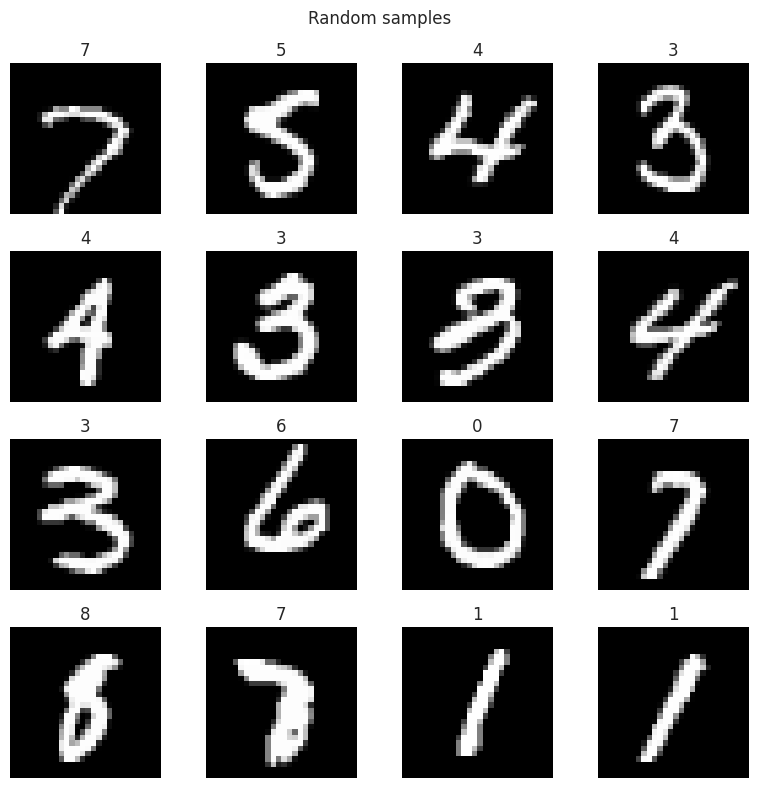

In [5]:
indexes = np.random.choice(range(0, X_train.shape[0]), size=16, replace=False)
samples = zip(X_train[indexes], y_train[indexes])

fig, axs = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('Random samples')

for ax, sample in zip(axs.flatten(), samples):
    ax.imshow(sample[0], cmap="gray")
    ax.set_title(sample[1])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Visualize the class distribution

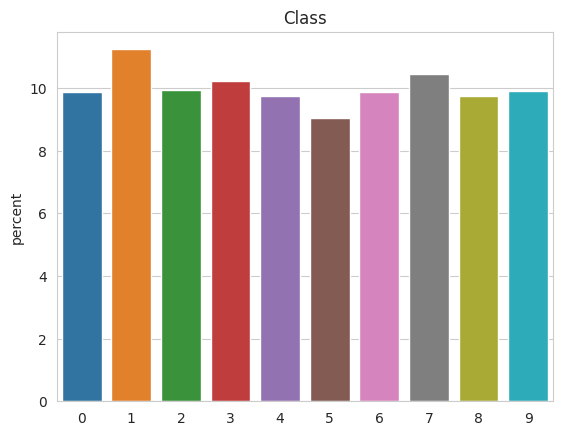

In [6]:
with sns.axes_style("whitegrid"):
    plt.figure()
    sns.countplot(x=y_train, hue=y_train, palette="tab10", stat="percent", legend=False)
    plt.title("Class")
    plt.show()

## Build the model

Use the simplest possible Convolutional Neural Network (CNN) architecture to classify the MNIST digits dataset.

In [7]:
number_classes = np.unique(y_train).size

model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(layers.Conv2D(8, kernel_size=(3, 3), strides=(2, 2), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(number_classes, activation="softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 13, 13, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        13,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,610 (53.16 KB)

 Trainable params: 13,610 (53.16 KB)

 Non-trainable params: 0 (0.00 B)

## Compile and train the model

In [8]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

epochs = 5
history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_validation, y_validation))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8996 - loss: 0.3609 - val_accuracy: 0.9316 - val_loss: 0.2515
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9375 - loss: 0.2220 - val_accuracy: 0.9496 - val_loss: 0.1886
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9485 - loss: 0.1831 - val_accuracy: 0.9544 - val_loss: 0.1665
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9550 - loss: 0.1594 - val_accuracy: 0.9586 - val_loss: 0.1498
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9601 - loss: 0.1400 - val_accuracy: 0.9612 - val_loss: 0.1338


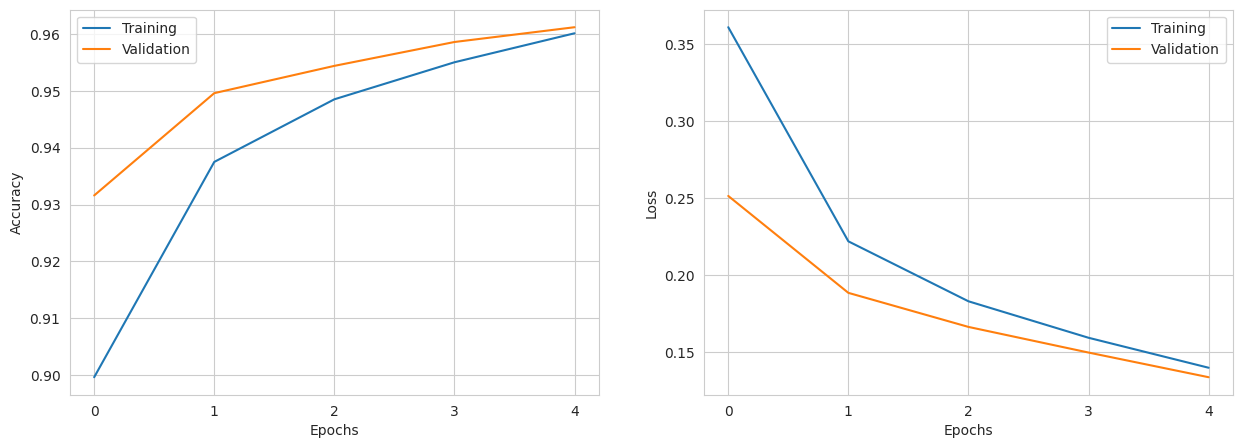

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_xticks(range(epochs))
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.legend(["Training", "Validation"])

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_xticks(range(epochs))
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend(["Training", "Validation"])

plt.show()

## Evaluate the model

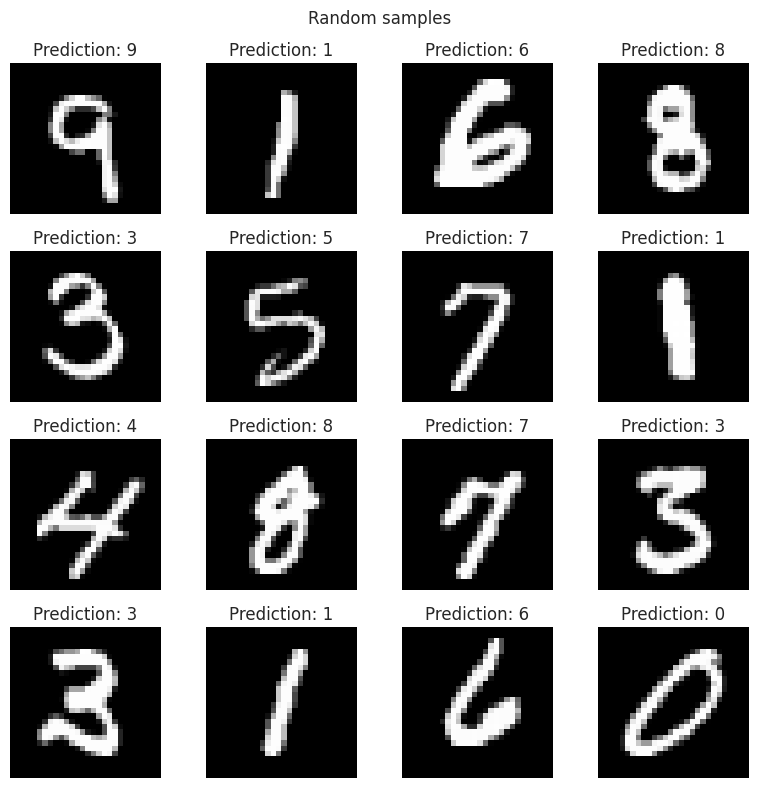

In [10]:
indexes = np.random.choice(range(0, X_test.shape[0]), size=16, replace=False)

fig, axs = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('Random samples')

for image, ax in zip(X_test[indexes], axs.flatten()):
    prediction_proba = model.predict(np.expand_dims(image, axis=0), verbose=0)
    ax.imshow(image, cmap="gray")
    ax.set_title("Prediction: " + str(np.argmax(prediction_proba)))
    ax.axis("off")

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0     0.9534    0.9899    0.9713       496
           1     0.9807    0.9912    0.9859       565
           2     0.9656    0.9427    0.9540       506
           3     0.9477    0.9800    0.9635       499
           4     0.9684    0.9761    0.9722       502
           5     0.9649    0.9756    0.9702       451
           6     0.9842    0.9561    0.9700       456
           7     0.9616    0.9525    0.9570       526
           8     0.9409    0.9429    0.9419       490
           9     0.9774    0.9352    0.9558       509

    accuracy                         0.9644      5000
   macro avg     0.9645    0.9642    0.9642      5000
weighted avg     0.9646    0.9644    0.9643      5000



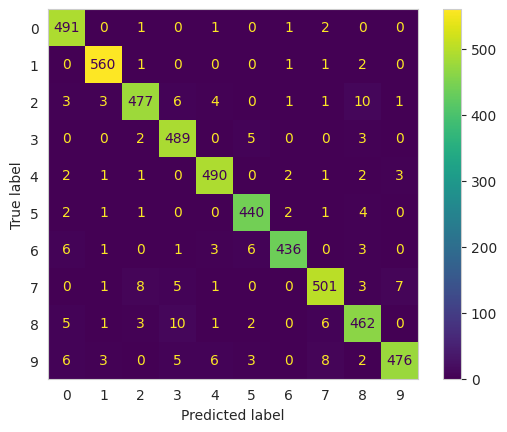

In [11]:
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.grid(False)
plt.show()

## Export the trained model

In [12]:
MODEL_DIR = "/tmp/digits_model"
version = 1
export_path = os.path.join(MODEL_DIR, str(version))
os.makedirs(export_path, exist_ok=True)
model.export(export_path)

Saved artifact at '/tmp/digits_model/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  140206489219728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140206489220880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140206489220112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140206489216272: TensorSpec(shape=(), dtype=tf.resource, name=None)


## Install TensorFlow Serving

In [13]:
%%bash
echo "deb http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal" | tee /etc/apt/sources.list.d/tensorflow-serving.list && \
curl https://storage.googleapis.com/tensorflow-serving-apt/tensorflow-serving.release.pub.gpg | apt-key add -

apt update && apt install tensorflow-model-server

deb http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal
OK
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [101 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,845 kB]
Get:7 http://storage.googleapis.com/tensorflow-serving-apt stable InRelease [3,026 B]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: apt-key is deprecated. Manage keyring files in trusted.gpg.d instead (see apt-key(8)).
100  2943  100  2943    0     0   8010      0 --:--:-- --:--:-- --:--:--  8019


W: http://storage.googleapis.com/tensorflow-serving-apt/dists/stable/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)




## Run the TensorFlow Model Server

In [14]:
os.environ["MODEL_DIR"] = MODEL_DIR

In [15]:
%%bash --bg
nohup tensorflow_model_server \
  --rest_api_port=8501 \
  --model_name=digits_model \
  --model_base_path="${MODEL_DIR}" >server.log 2>&1

## Make prediction requests to the TensorFlow Model Server

In [24]:
indexes = np.random.choice(range(0, X_test.shape[0]), size=16, replace=False)
data = json.dumps({"signature_name": "serving_default", "instances": X_test[indexes].tolist()})
headers = {"content-type": "application/json"}
json_response = requests.post('http://127.0.0.1:8501/v1/models/digits_model:predict', data=data, headers=headers)
predictions = json.loads(json_response.text)['predictions']

## Visualize the predictions

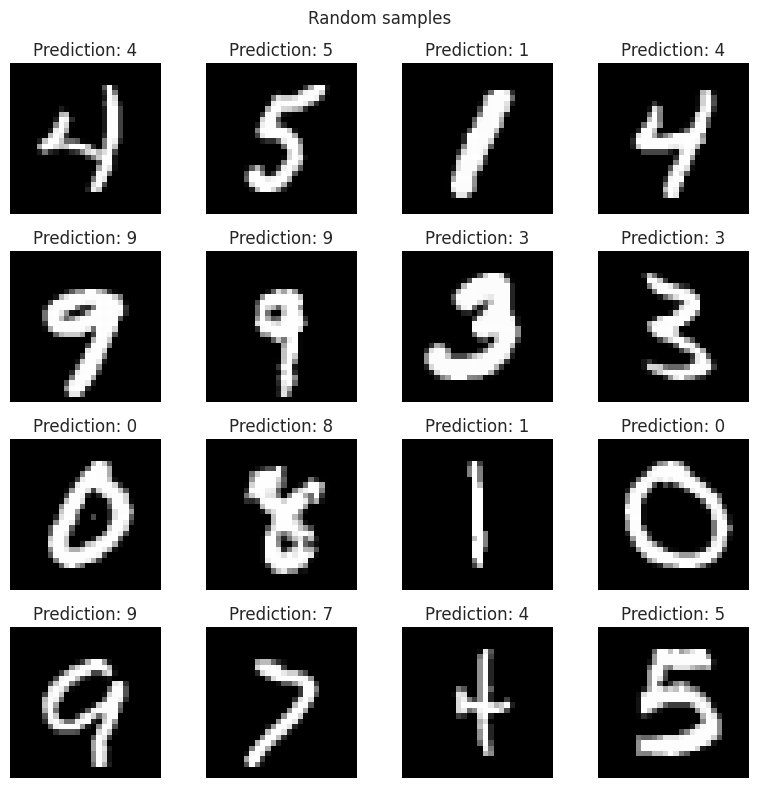

In [25]:
fig, axs = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('Random samples')

for i, (image, ax) in enumerate(zip(X_test[indexes], axs.flatten())):
    ax.imshow(image, cmap="gray")
    ax.set_title("Prediction: " + str(np.argmax(predictions[i])))
    ax.axis("off")

plt.tight_layout()
plt.show()